IMDB Sentiment Analysis with RNN

In [1]:
!conda create -n dl_rnn_latest_env python=3.10 -y
!conda activate dl_rnn_latest_env
!pip install numpy==1.26.4 tensorflow keras pandas scikit-learn matplotlib seaborn nltk wordcloud 

Retrieving notices: ...working... done

'C:\Users\Herath kumara\anaconda3\envs\dl_rnn_latest_env'
Spaces in paths can sometimes be problematic. To minimize issues,
make sure you activate your environment before running any executables!




Channels:
 - defaults
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\Herath kumara\anaconda3\envs\dl_rnn_latest_env

  added / updated specs:
    - python=3.10


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    setuptools-80.9.0          |  py310haa95532_0         1.4 MB
    ------------------------------------------------------------
                                           Total:         1.4 MB

The following NEW packages will be INSTALLED:

  bzip2              pkgs/main/win-64::bzip2-1.0.8-h2bbff1b_6 
  ca-certificates    pkgs/main/win-64::ca-certificates-2025.9.9-haa95532_0 
  expat              pkgs/main/win-64::expat-2.7.1-h8ddb27b_0 
  libffi             pkgs/main/win-64::libffi-3.4.4-hd77b12b_1 
  libzlib            pkgs/main/win-64::libzlib-1.3.1-h02ab6af_0 
  openssl            pkgs/main/win-64::openssl-3.0.18-h

In [2]:

# IMDB Sentiment Analysis using RNN Variants
# =========================================================
# Author: Tharinduni Herath
# Model: Vanilla RNN, Stacked RNN, Bidirectional RNN
# Dataset: IMDB 50K Movie Reviews (Kaggle)
# =========================================================

# --- Import Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, os, time
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, Dense, Dropout, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import Constant
import tensorflow as tf

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

# --- Load Dataset ---
df = pd.read_csv("IMDB Dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

[nltk_data] Downloading package stopwords to C:\Users\Herath
[nltk_data]     kumara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Herath
[nltk_data]     kumara\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


C:\Users\Herath kumara\AppData\Local\Temp\ipykernel_8148\2481277481.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df, palette="viridis")


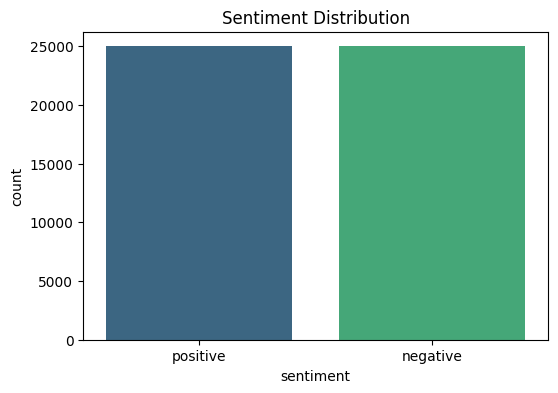

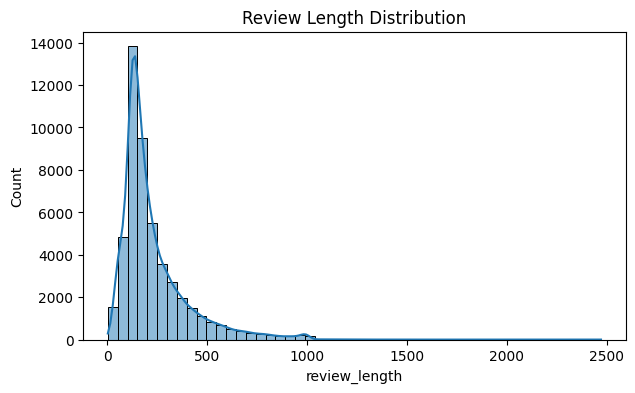

In [4]:
# =========================================================
# 1. Dataset Overview & EDA
# =========================================================

# Label distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="sentiment", data=df, palette="viridis")
plt.title("Sentiment Distribution")
plt.show()

# Review lengths
df["review_length"] = df["review"].apply(lambda x: len(x.split()))
plt.figure(figsize=(7, 4))
sns.histplot(df["review_length"], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.show()



In [5]:
# =========================================================
# 🧹 2. Text Cleaning & Preprocessing
# =========================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)  # remove HTML
    text = re.sub(r"<.*?>", " ", text)    # remove leftover 'br'
    text = re.sub(r"\bbr\b", " ", text)
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\d+", "", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply cleaning
df["clean_review"] = df["review"].apply(clean_text)

# Encode labels
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

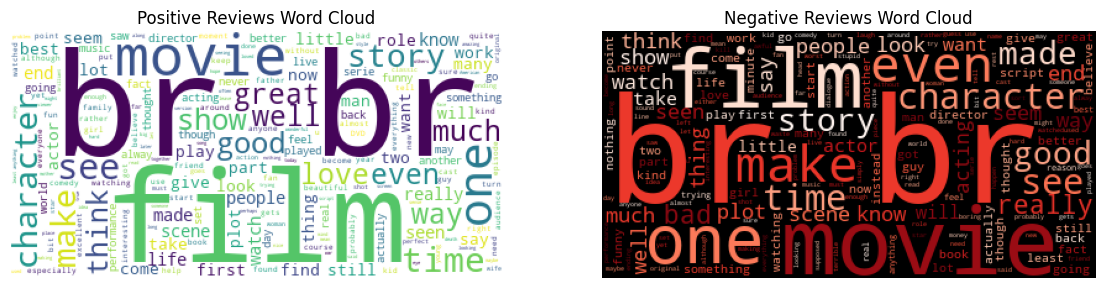

In [6]:
# Word clouds for positive and negative
pos_text = " ".join(df[df["sentiment"] == "positive"]["review"])
neg_text = " ".join(df[df["sentiment"] == "negative"]["review"])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(WordCloud(max_words=200, background_color="white").generate(pos_text))
ax[0].set_title("Positive Reviews Word Cloud")
ax[1].imshow(WordCloud(max_words=200, background_color="black", colormap='Reds').generate(neg_text))
ax[1].set_title("Negative Reviews Word Cloud")
for a in ax: a.axis("off")
plt.show()

In [7]:
# =========================================================
# 🔢 3. Tokenization and Padding
# =========================================================

MAX_VOCAB = 20000
MAX_LEN = 250
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB)
tokenizer.fit_on_texts(df["clean_review"])
X = tokenizer.texts_to_sequences(df["clean_review"])
X = pad_sequences(X, maxlen=MAX_LEN, padding="post", truncating="post")
y = df["label"].values

In [8]:
# =========================================================
# 💾 4. Load Pretrained GloVe Embeddings
# =========================================================

embeddings_index = {}
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coeffs

embedding_matrix = np.zeros((MAX_VOCAB, EMBED_DIM))
for word, i in tokenizer.word_index.items():
    if i < MAX_VOCAB:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [9]:
# =========================================================
# 🧠 5. Define RNN Model Variants
# =========================================================

def create_rnn_model(model_type="vanilla"):
    model = Sequential()
    model.add(Embedding(MAX_VOCAB, EMBED_DIM,
                        embeddings_initializer=Constant(embedding_matrix),
                        input_length=MAX_LEN, trainable=False))
    
    if model_type == "vanilla":
        model.add(SimpleRNN(128, activation='tanh'))
    
    elif model_type == "stacked":
        model.add(SimpleRNN(128, activation='tanh', return_sequences=True))
        model.add(Dropout(0.3))
        model.add(SimpleRNN(64, activation='tanh'))
    
    elif model_type == "birnn":
        model.add(Bidirectional(SimpleRNN(128, activation='tanh')))
    
    model.add(Dropout(0.4))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=1e-3),
                  metrics=['accuracy'])
    return model

In [10]:
# =========================================================
# ⚙️ 6. Training Configuration
# =========================================================

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_sched = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

In [11]:
# =========================================================
# 🚀 7. Train All RNN Variants
# =========================================================

models = {}
histories = {}
model_types = ["vanilla", "stacked", "birnn"]

for mtype in model_types:
    print(f"\nTraining {mtype.upper()} RNN...")
    model = create_rnn_model(mtype)
    start = time.time()
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=10,
                        batch_size=128,
                        callbacks=[early_stop, lr_sched],
                        verbose=1)
    end = time.time()
    models[mtype] = model
    histories[mtype] = (history, end - start)


Training VANILLA RNN...


C:\Users\Herath kumara\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.5018 - loss: 0.7097 - val_accuracy: 0.5064 - val_loss: 0.6969 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.5012 - loss: 0.7034 - val_accuracy: 0.5039 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.5003 - loss: 0.6968 - val_accuracy: 0.5021 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.4995 - loss: 0.6963 - val_accuracy: 0.4998 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.4987 - loss: 0.6947 - val_accuracy: 0.5037 - val_loss: 0.6928 - learning_rate: 0.0010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.5031 - loss: 0.6939 - val_accuracy: 0.5038 - val_loss: 0.6929 - learning_rate: 5.0000e-04

Training STACKED RNN...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 192

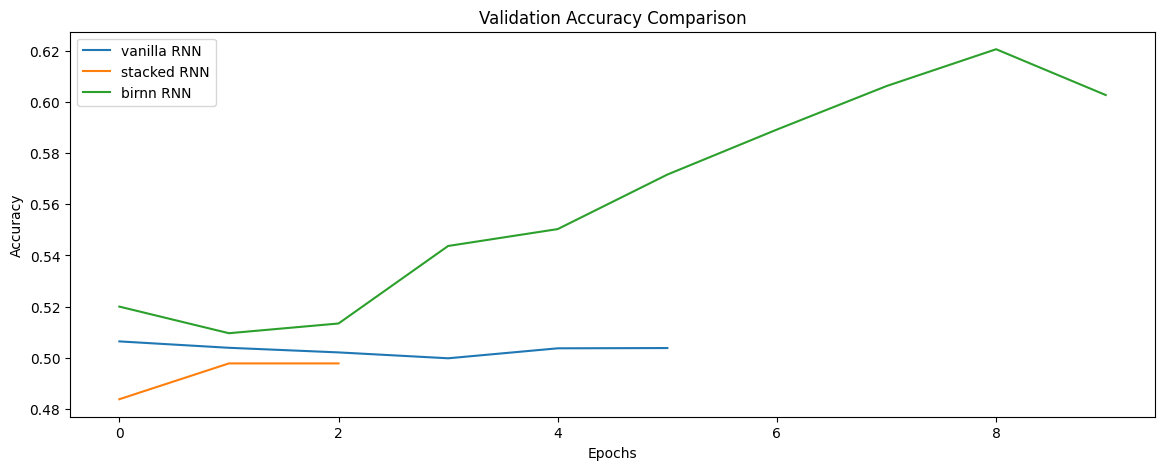

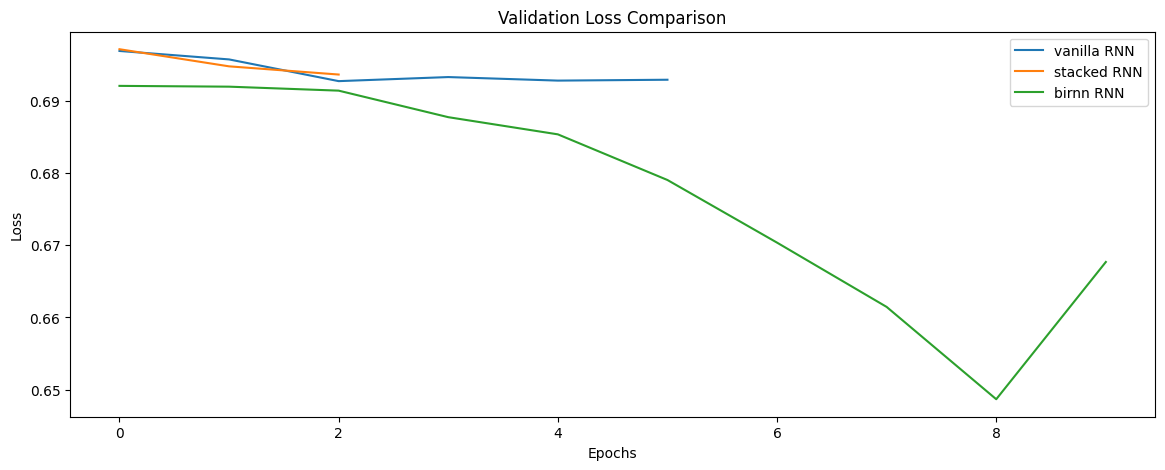


Model Comparison:

     Model  Val_Accuracy  Val_Loss  Train_Time(s)
0  VANILLA        0.5064    0.6927         151.74
1  STACKED        0.4978    0.6936         184.60
2    BIRNN        0.6206    0.6487         375.49


C:\Users\Herath kumara\AppData\Local\Temp\ipykernel_8148\240607442.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Val_Accuracy", data=results_df, palette="cool")


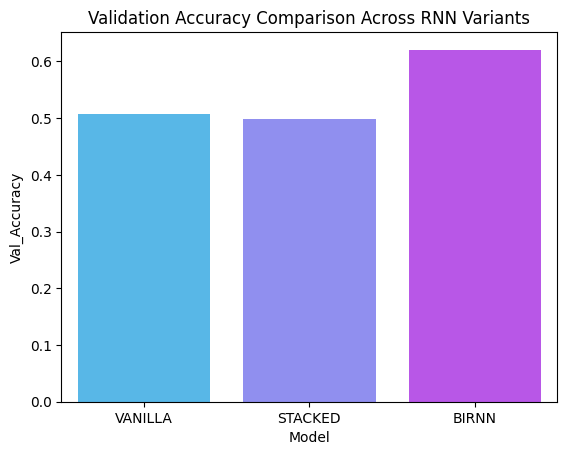

In [12]:
# =========================================================
# 📊 8. Evaluation & Visualization
# =========================================================

def plot_history(histories):
    plt.figure(figsize=(14, 5))
    for mtype, (history, _) in histories.items():
        plt.plot(history.history['val_accuracy'], label=f'{mtype} RNN')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.figure(figsize=(14, 5))
    for mtype, (history, _) in histories.items():
        plt.plot(history.history['val_loss'], label=f'{mtype} RNN')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(histories)

# Compare final accuracy
results = []
for mtype, (history, duration) in histories.items():
    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    results.append((mtype.upper(), round(val_acc, 4), round(val_loss, 4), round(duration, 2)))

results_df = pd.DataFrame(results, columns=["Model", "Val_Accuracy", "Val_Loss", "Train_Time(s)"])
print("\nModel Comparison:\n")
print(results_df)

sns.barplot(x="Model", y="Val_Accuracy", data=results_df, palette="cool")
plt.title("Validation Accuracy Comparison Across RNN Variants")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step


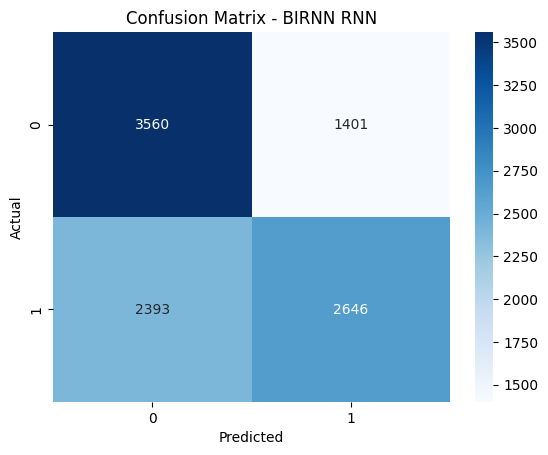


Classification Report:

              precision    recall  f1-score   support

    Negative       0.60      0.72      0.65      4961
    Positive       0.65      0.53      0.58      5039

    accuracy                           0.62     10000
   macro avg       0.63      0.62      0.62     10000
weighted avg       0.63      0.62      0.62     10000


Review: In the 2nd of his Historical Martial Arts films, Chiba portrays his real life sensei Mas Oyama. The film even recreates Oyama's incredible feat of killing a raging bull with his bare hands (Oyama did ...
True: Negative | Predicted: Negative

Review: We loved this movie because it was so entertaining and off beat-- Not your usual Hollywood drivel.<br /><br />My husband had a Blockbuster coupon and passed on a string of new releases of violent Holl...
True: Negative | Predicted: Negative

Review: Grey Gardens is a world unto itself. Edith and Little Edie live in near total isolation, eating ice cream and liver pate in a makeshift kit

In [13]:
# =========================================================
# 🧾 9. Confusion Matrix & Sample Predictions (Best Model)
# =========================================================

best_model_type = results_df.sort_values(by="Val_Accuracy", ascending=False).iloc[0]["Model"].lower()
best_model = models[best_model_type]
y_pred = (best_model.predict(X_val) > 0.5).astype("int32")

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_type.upper()} RNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=["Negative", "Positive"]))

# Sample predictions
sample_idx = np.random.choice(len(X_val), 5)
for i in sample_idx:
    print(f"\nReview: {df.iloc[i]['review'][:200]}...")
    print(f"True: {'Positive' if y_val[i]==1 else 'Negative'} | Predicted: {'Positive' if y_pred[i]==1 else 'Negative'}")